In [50]:
from pathlib import Path

MODEL_DIR = Path("../models")

In [51]:
from graphies.predict.models import GRU
from graphies.predict import GraphiesModel, GraphiesTokenizer

tokenizer = GraphiesTokenizer(MODEL_DIR / "fastaselfies-data/fastaselfies.json")
model = GraphiesModel.from_checkpoint(
    checkpoint=MODEL_DIR / "fastaselfies-data/model.pt",
    tokenizer=tokenizer,
    model_cls=GRU,
    device="cuda",
)

In [52]:
from datasets import load_dataset

hf_dataset = load_dataset("lukaskim/ChEMBL-36", "molecule_target_pairs", split="train")

In [53]:
target_chembl_id = "CHEMBL219"
control_chembl_id = ["CHEMBL243"]

ref = hf_dataset.filter(lambda x: x["target_chembl_id"] == target_chembl_id)
control = hf_dataset.filter(lambda x: x["target_chembl_id"] in control_chembl_id)

In [54]:
len(ref), len(control)

(4399, 6403)

In [55]:
def generate_ligands(seq):
    prompt = "".join([f"[{c}]" for c in seq.lower()]) + "[ENDBEGIN]"
    graphies = [
        seq
        for _ in range(4)
        for seq in model.extend(prompt, temperature=0.70, top_p=0.90, num=512)
    ]
    ligands = []
    for seq in graphies:
        lig = tokenizer.strip(seq).split("[ENDBEGIN]")[1]
        ligands.append(lig)
    return ligands


ligands = generate_ligands(ref["sequence"][0])
control_ligands = generate_ligands(control["sequence"][0])

In [56]:
import selfies as sf
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator, DataStructs

mfpgen = rdFingerprintGenerator.GetMorganGenerator()


def calculate_fingerprints(smiles):
    fpts = []
    for smi in smiles:
        mol = Chem.MolFromSmiles(smi)
        fp = mfpgen.GetFingerprint(mol)
        fpts.append(fp)
    return fpts


def calculate_similarity(smiles: list[str], ref_fp):
    output = {
        "max": [],
        "mean": [],
        "min": [],
    }

    for smi in smiles:
        mol = Chem.MolFromSmiles(smi)
        fp = mfpgen.GetFingerprint(mol)
        sim = DataStructs.BulkTanimotoSimilarity(fp, ref_fp)
        output["max"].append(max(sim))
        output["mean"].append(sum(sim) / len(sim))
        output["min"].append(min(sim))
    return output


ref_smiles = ref["canonical_smiles"]
lig_smiles = [sf.decoder(lig) for lig in ligands]
control_smiles = [sf.decoder(lig) for lig in control_ligands]

ref_fp = calculate_fingerprints(ref_smiles)
lig_fp = calculate_fingerprints(lig_smiles)
control_fp = calculate_fingerprints(control_smiles)

result = calculate_similarity(lig_smiles, ref_fp)
control_result = calculate_similarity(control_smiles, ref_fp)

control_control_result = calculate_similarity(control_smiles, control_fp)
ligand_ligand_result = calculate_similarity(lig_smiles, lig_fp)
control_ligand_result = calculate_similarity(control_smiles, lig_fp)
ligand_control_result = calculate_similarity(lig_smiles, control_fp)

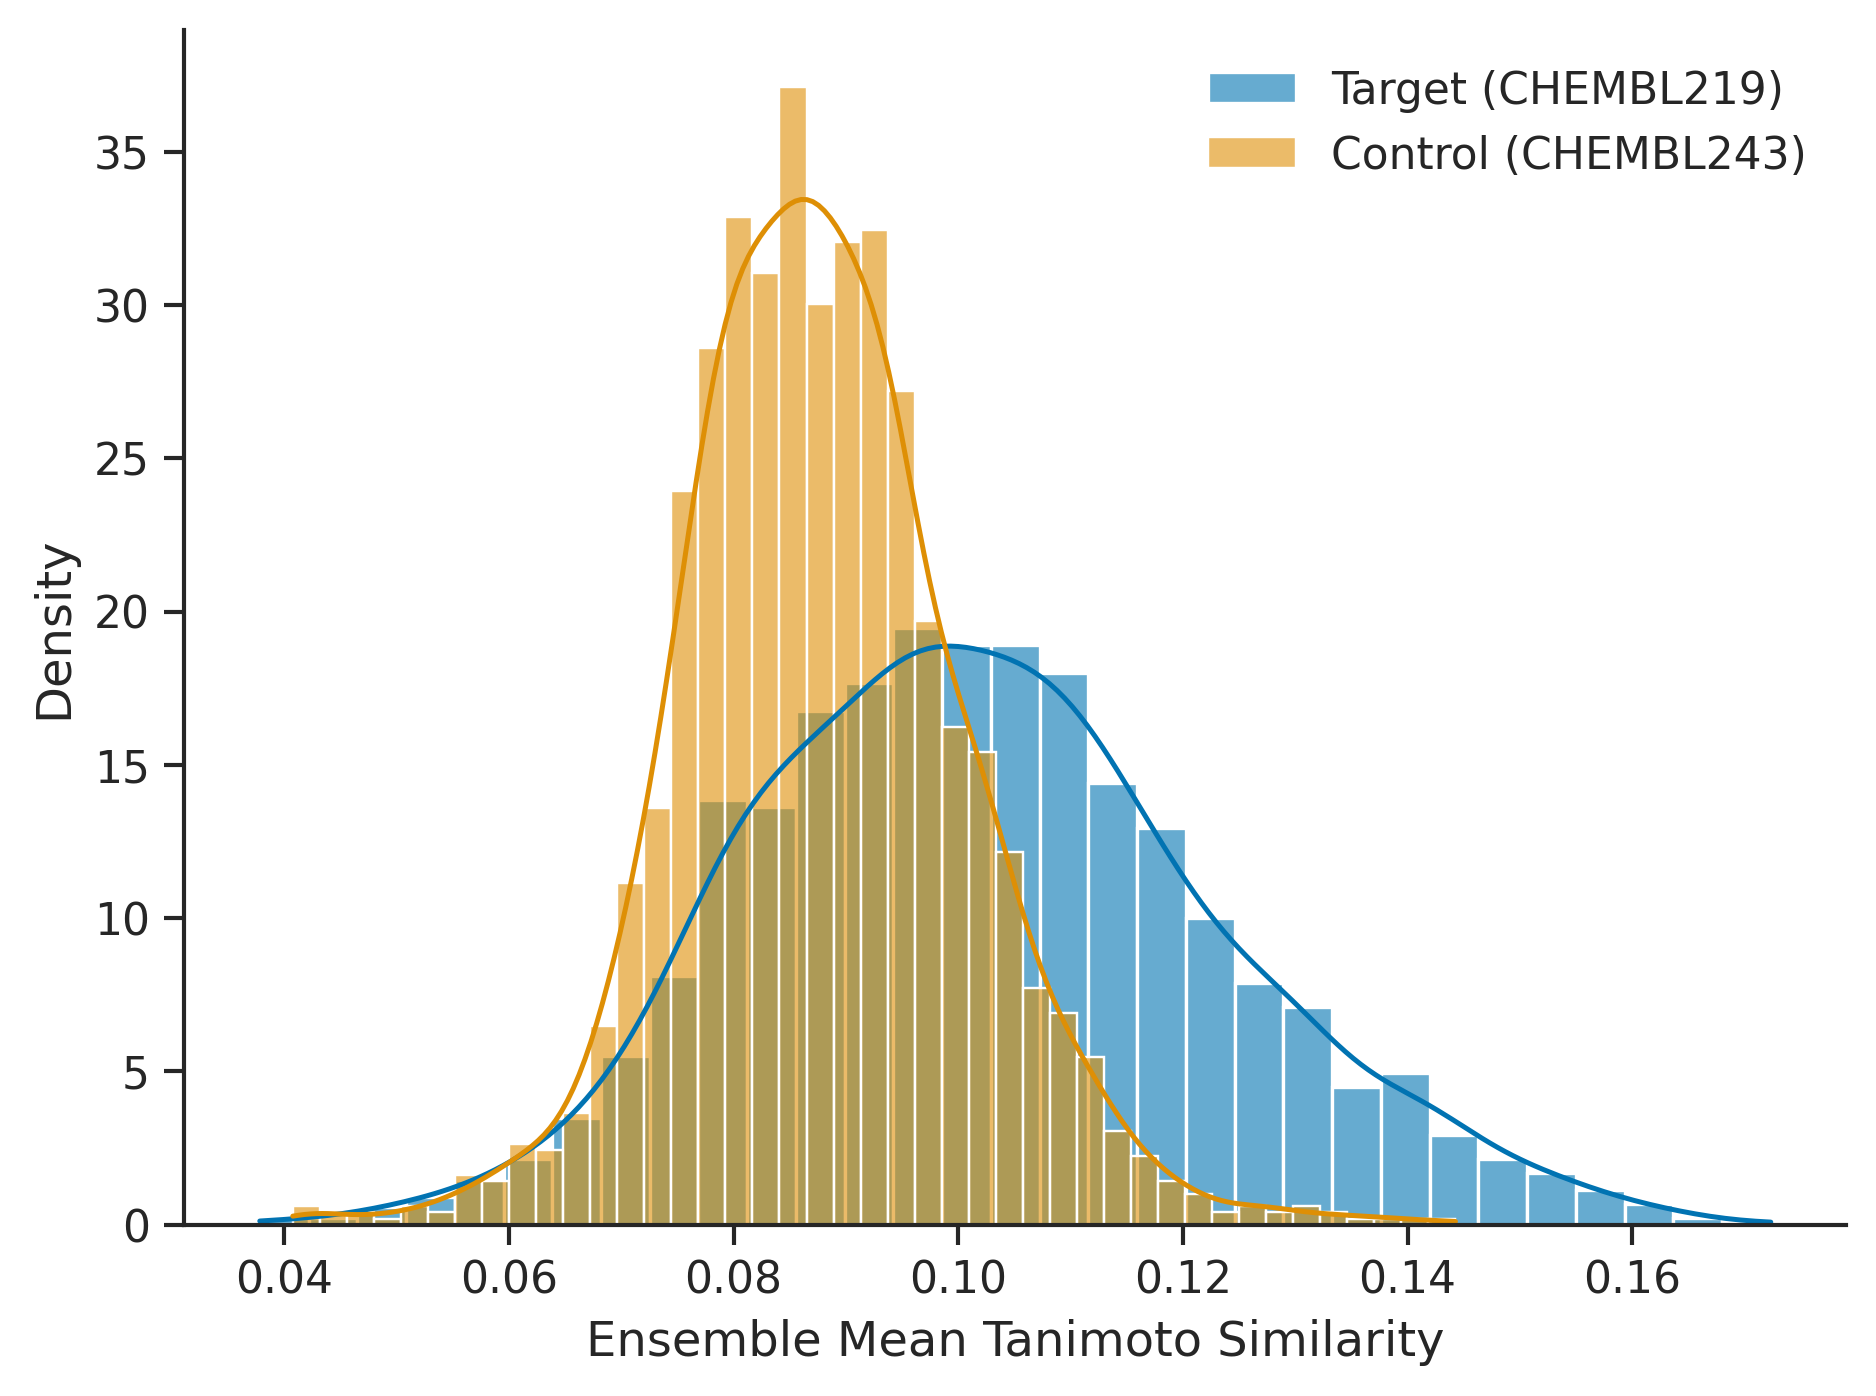

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("ticks")
sns.set_context("paper", font_scale=1.2)

palette = sns.color_palette("colorblind")

fig, ax = plt.subplots(1, 1, figsize=(6.4, 4.8), dpi=300)

sns.histplot(
    result["mean"],
    stat="density",
    kde=True,
    ax=ax,
    color=palette[0],
    label="Target (CHEMBL219)",
    alpha=0.6,
)
sns.histplot(
    control_result["mean"],
    stat="density",
    kde=True,
    ax=ax,
    color=palette[1],
    label="Control (CHEMBL243)",
    alpha=0.6,
)

ax.set_xlabel("Ensemble Mean Tanimoto Similarity")
ax.set_ylabel("Density")
# ax.set_xlim(0, 1)
ax.legend(frameon=False)
sns.despine(ax=ax)
fig.tight_layout()
plt.show()

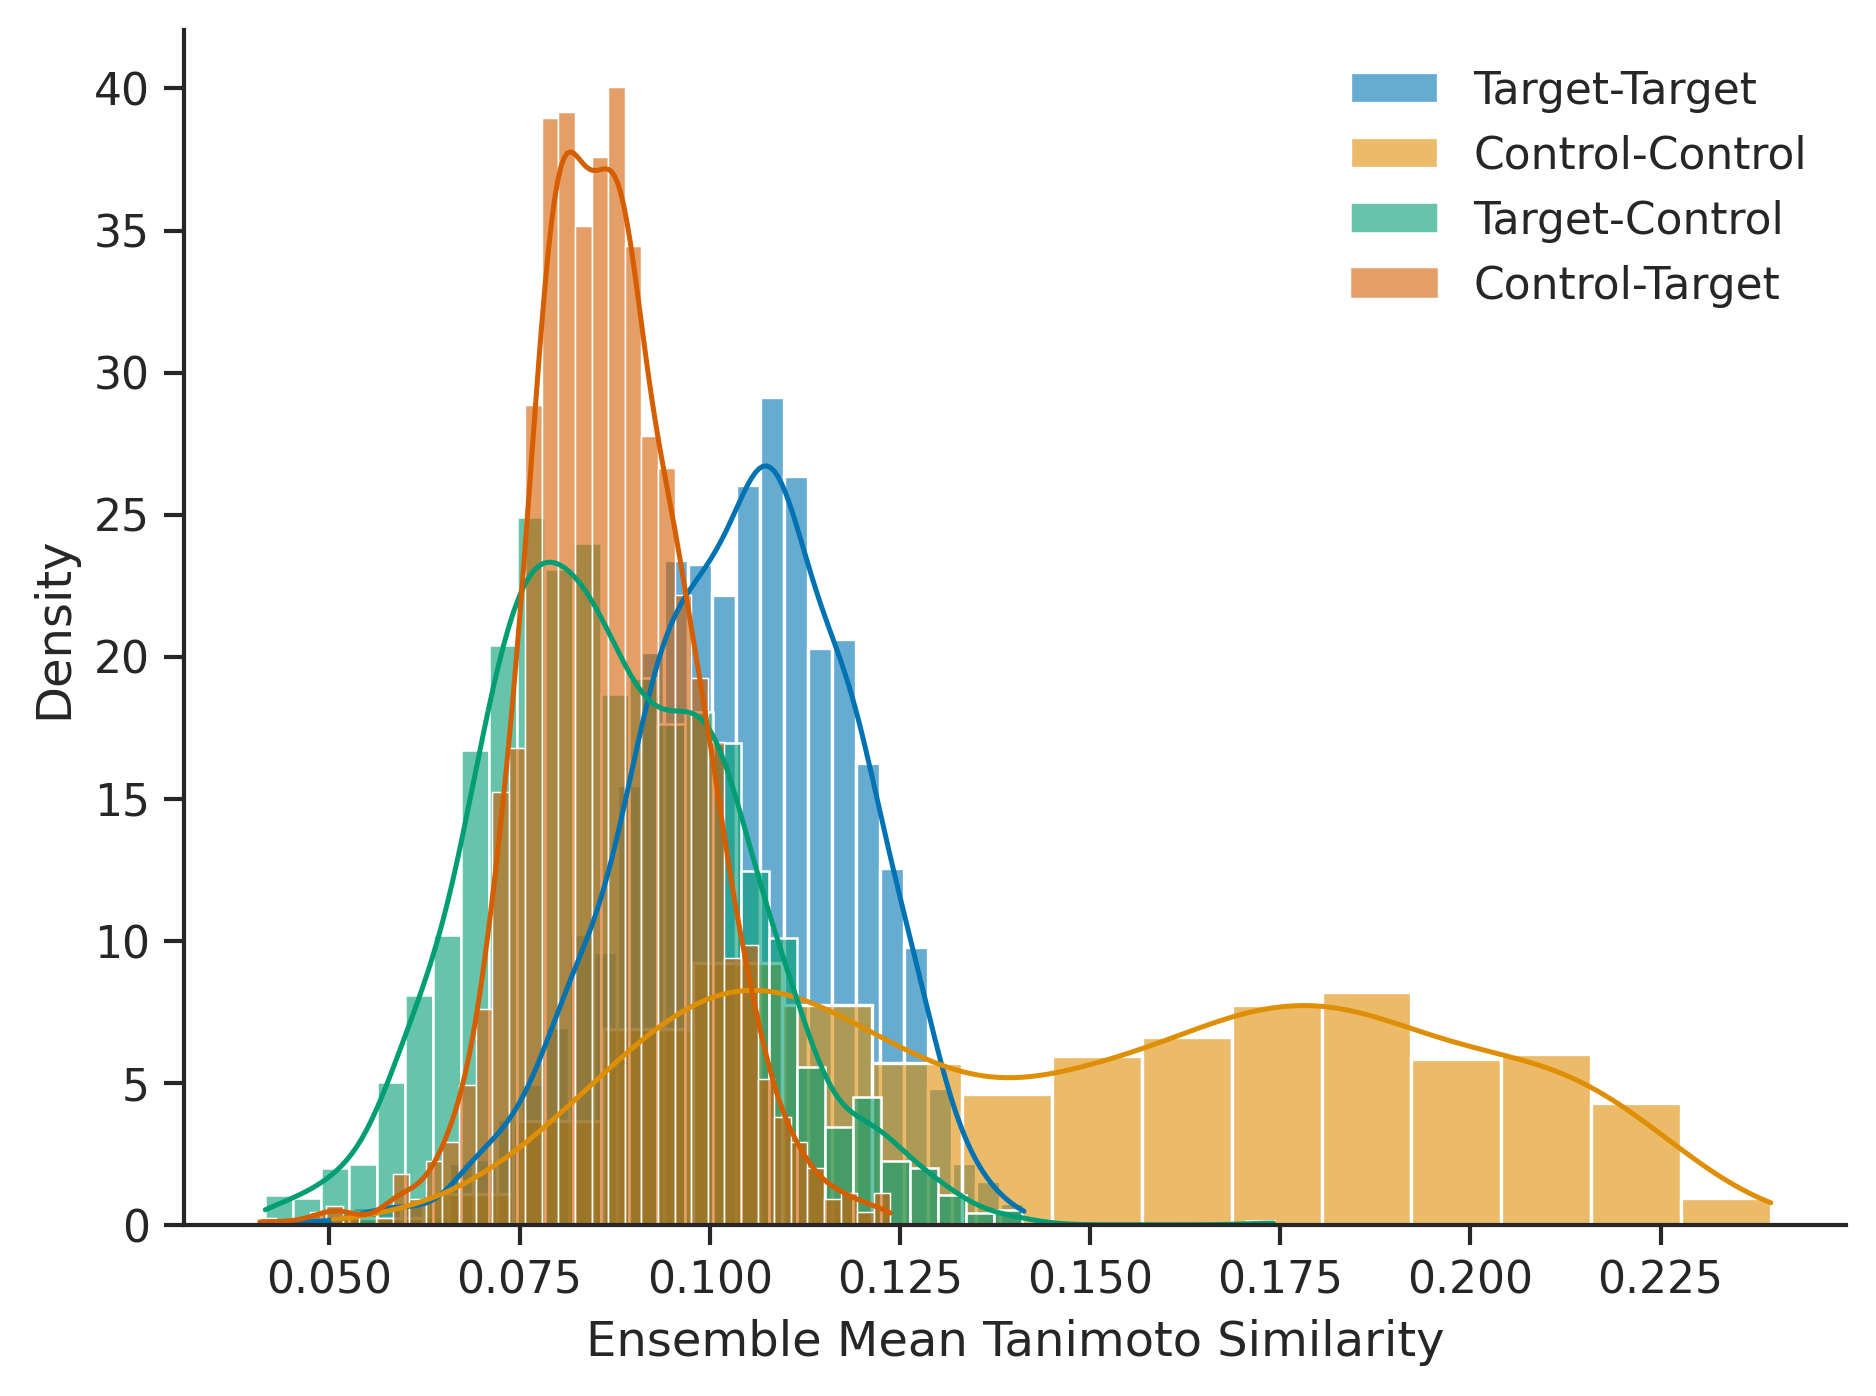

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("ticks")
sns.set_context("paper", font_scale=1.2)

palette = sns.color_palette("colorblind")

fig, ax = plt.subplots(1, 1, figsize=(6.4, 4.8), dpi=300)

sns.histplot(
    ligand_ligand_result["mean"],
    stat="density",
    kde=True,
    ax=ax,
    color=palette[0],
    label="Target-Target",
    alpha=0.6,
)
sns.histplot(
    control_control_result["mean"],
    stat="density",
    kde=True,
    ax=ax,
    color=palette[1],
    label="Control-Control",
    alpha=0.6,
)
sns.histplot(
    ligand_control_result["mean"],
    stat="density",
    kde=True,
    ax=ax,
    color=palette[2],
    label="Target-Control",
    alpha=0.6,
)
sns.histplot(
    control_ligand_result["mean"],
    stat="density",
    kde=True,
    ax=ax,
    color=palette[3],
    label="Control-Target",
    alpha=0.6,
)

ax.set_xlabel("Ensemble Mean Tanimoto Similarity")
ax.set_ylabel("Density")
# ax.set_xlim(0, 1)
ax.legend(frameon=False)
sns.despine(ax=ax)
fig.tight_layout()
plt.show()